In [1]:
import numpy as np
import polars as pl
from pathlib import Path

import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 16

# 2.A : Few trajectories + Mean + Theory (Homogeneous)

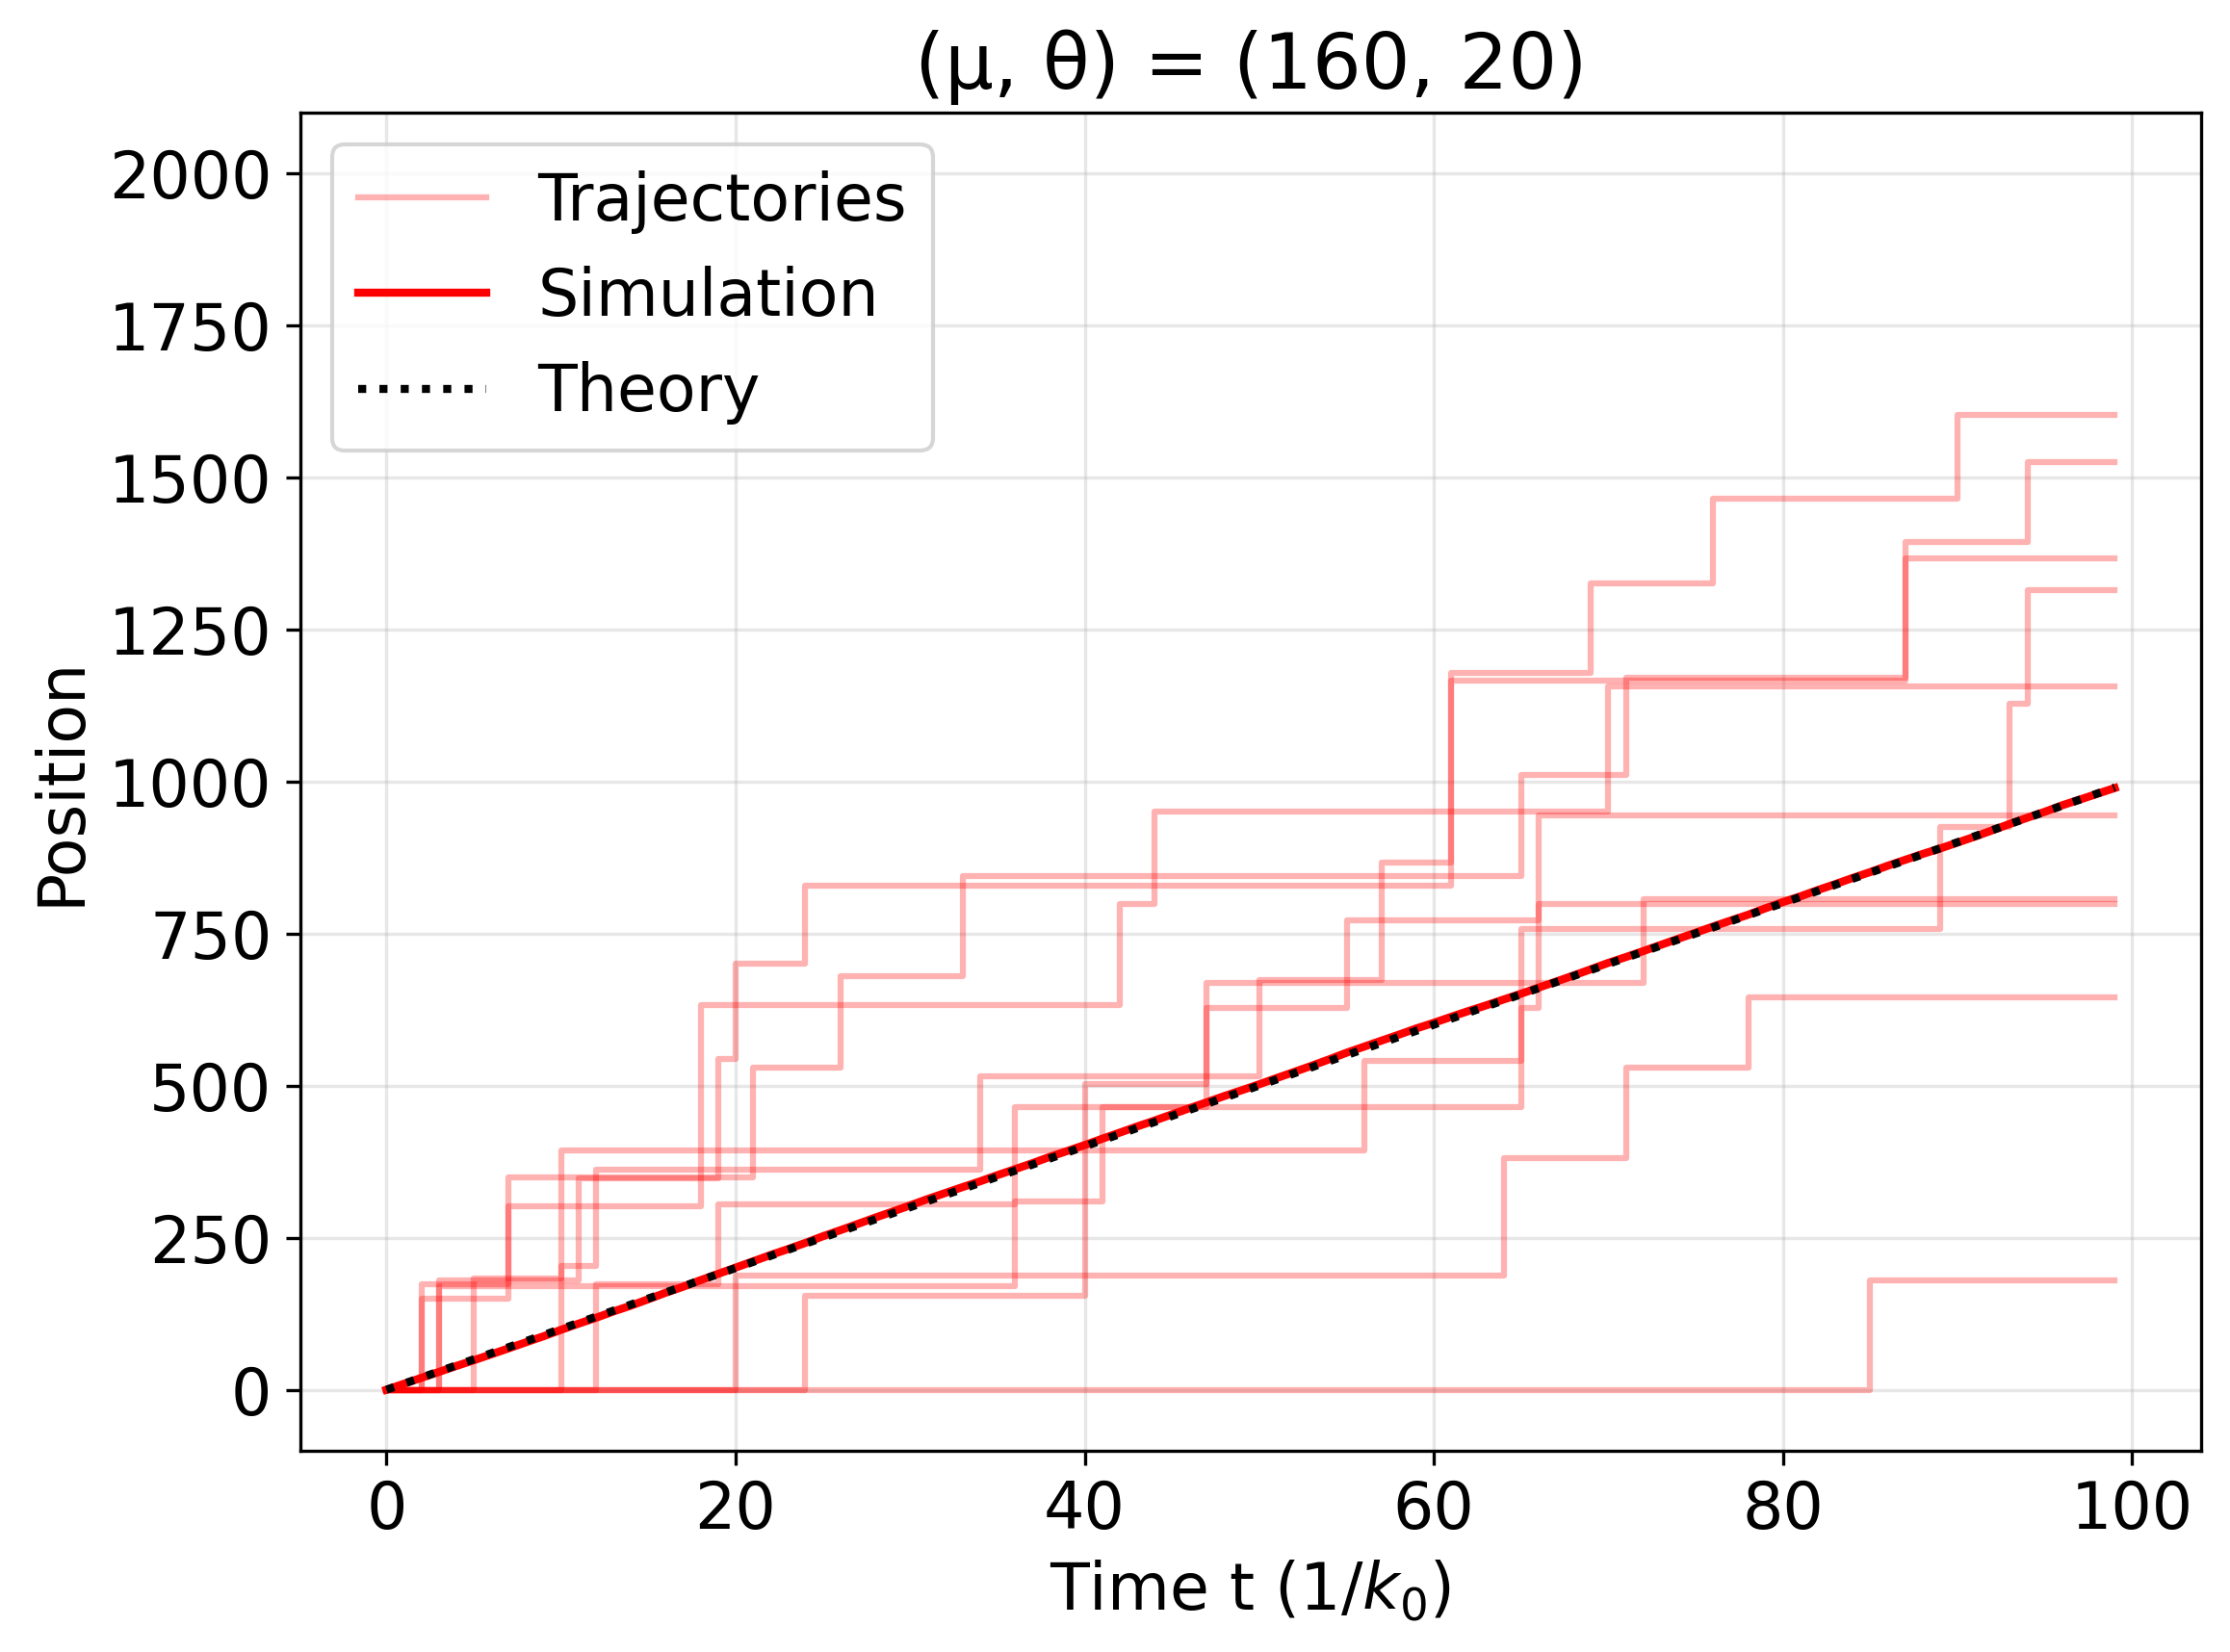

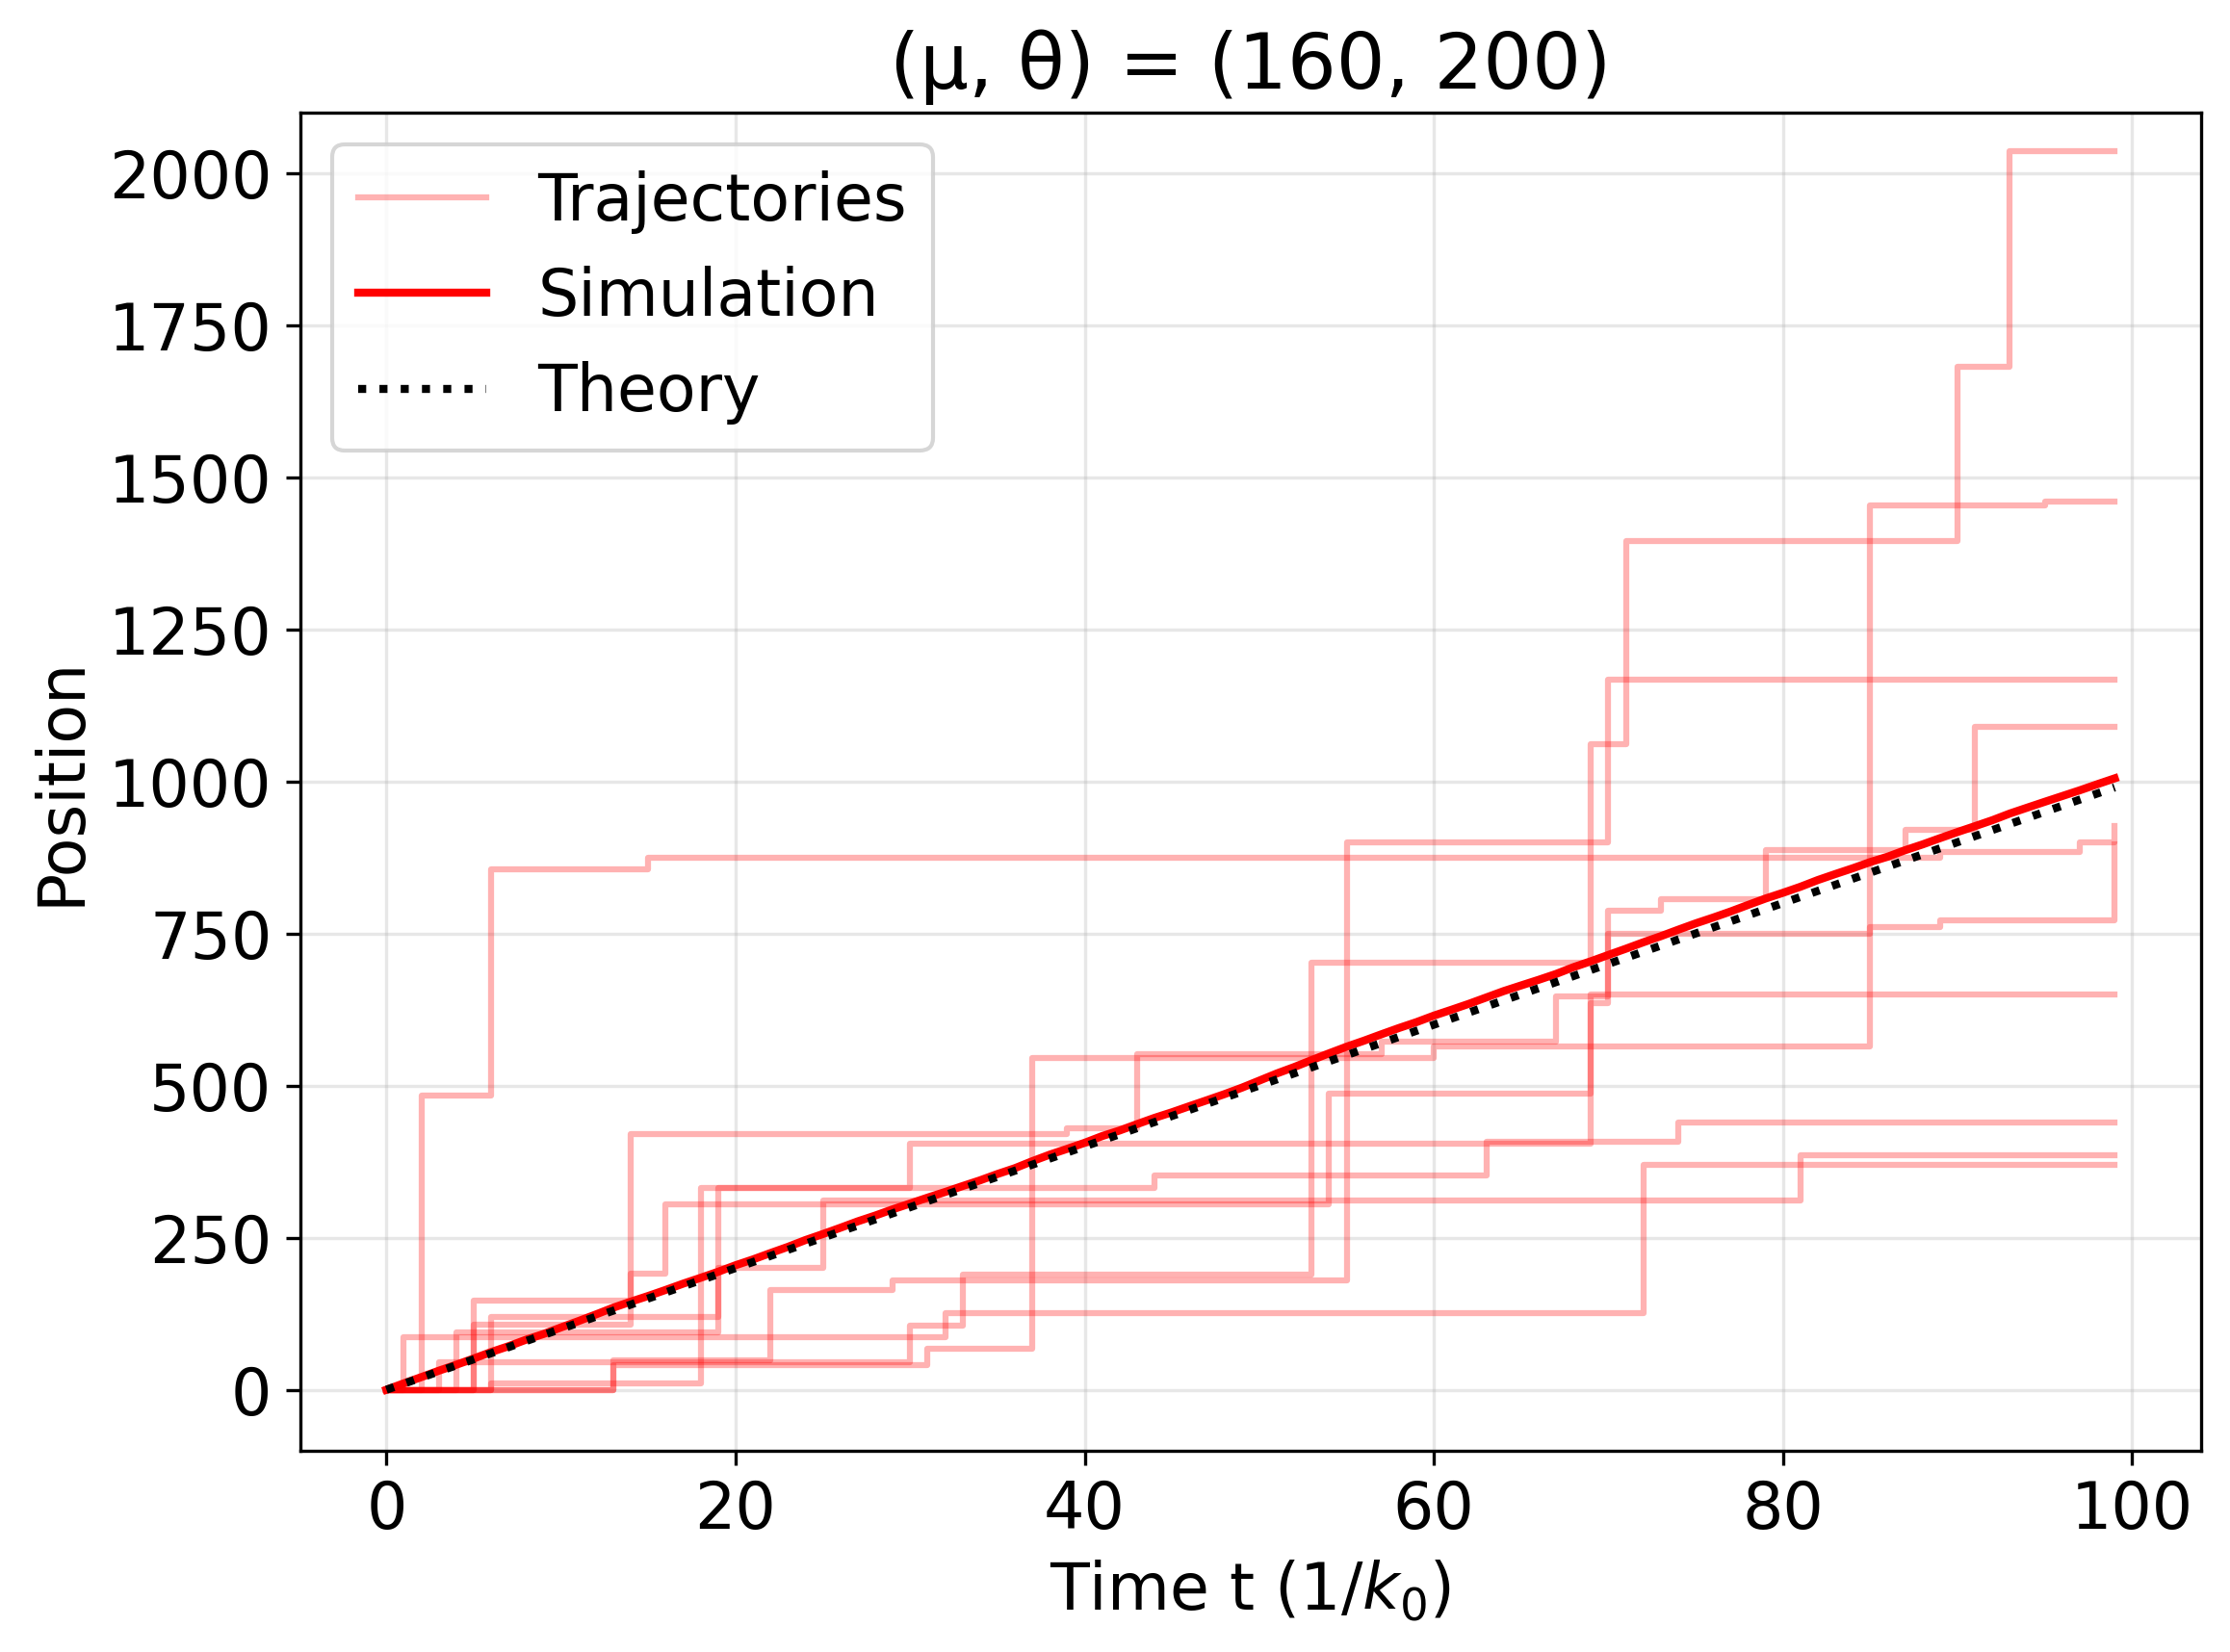

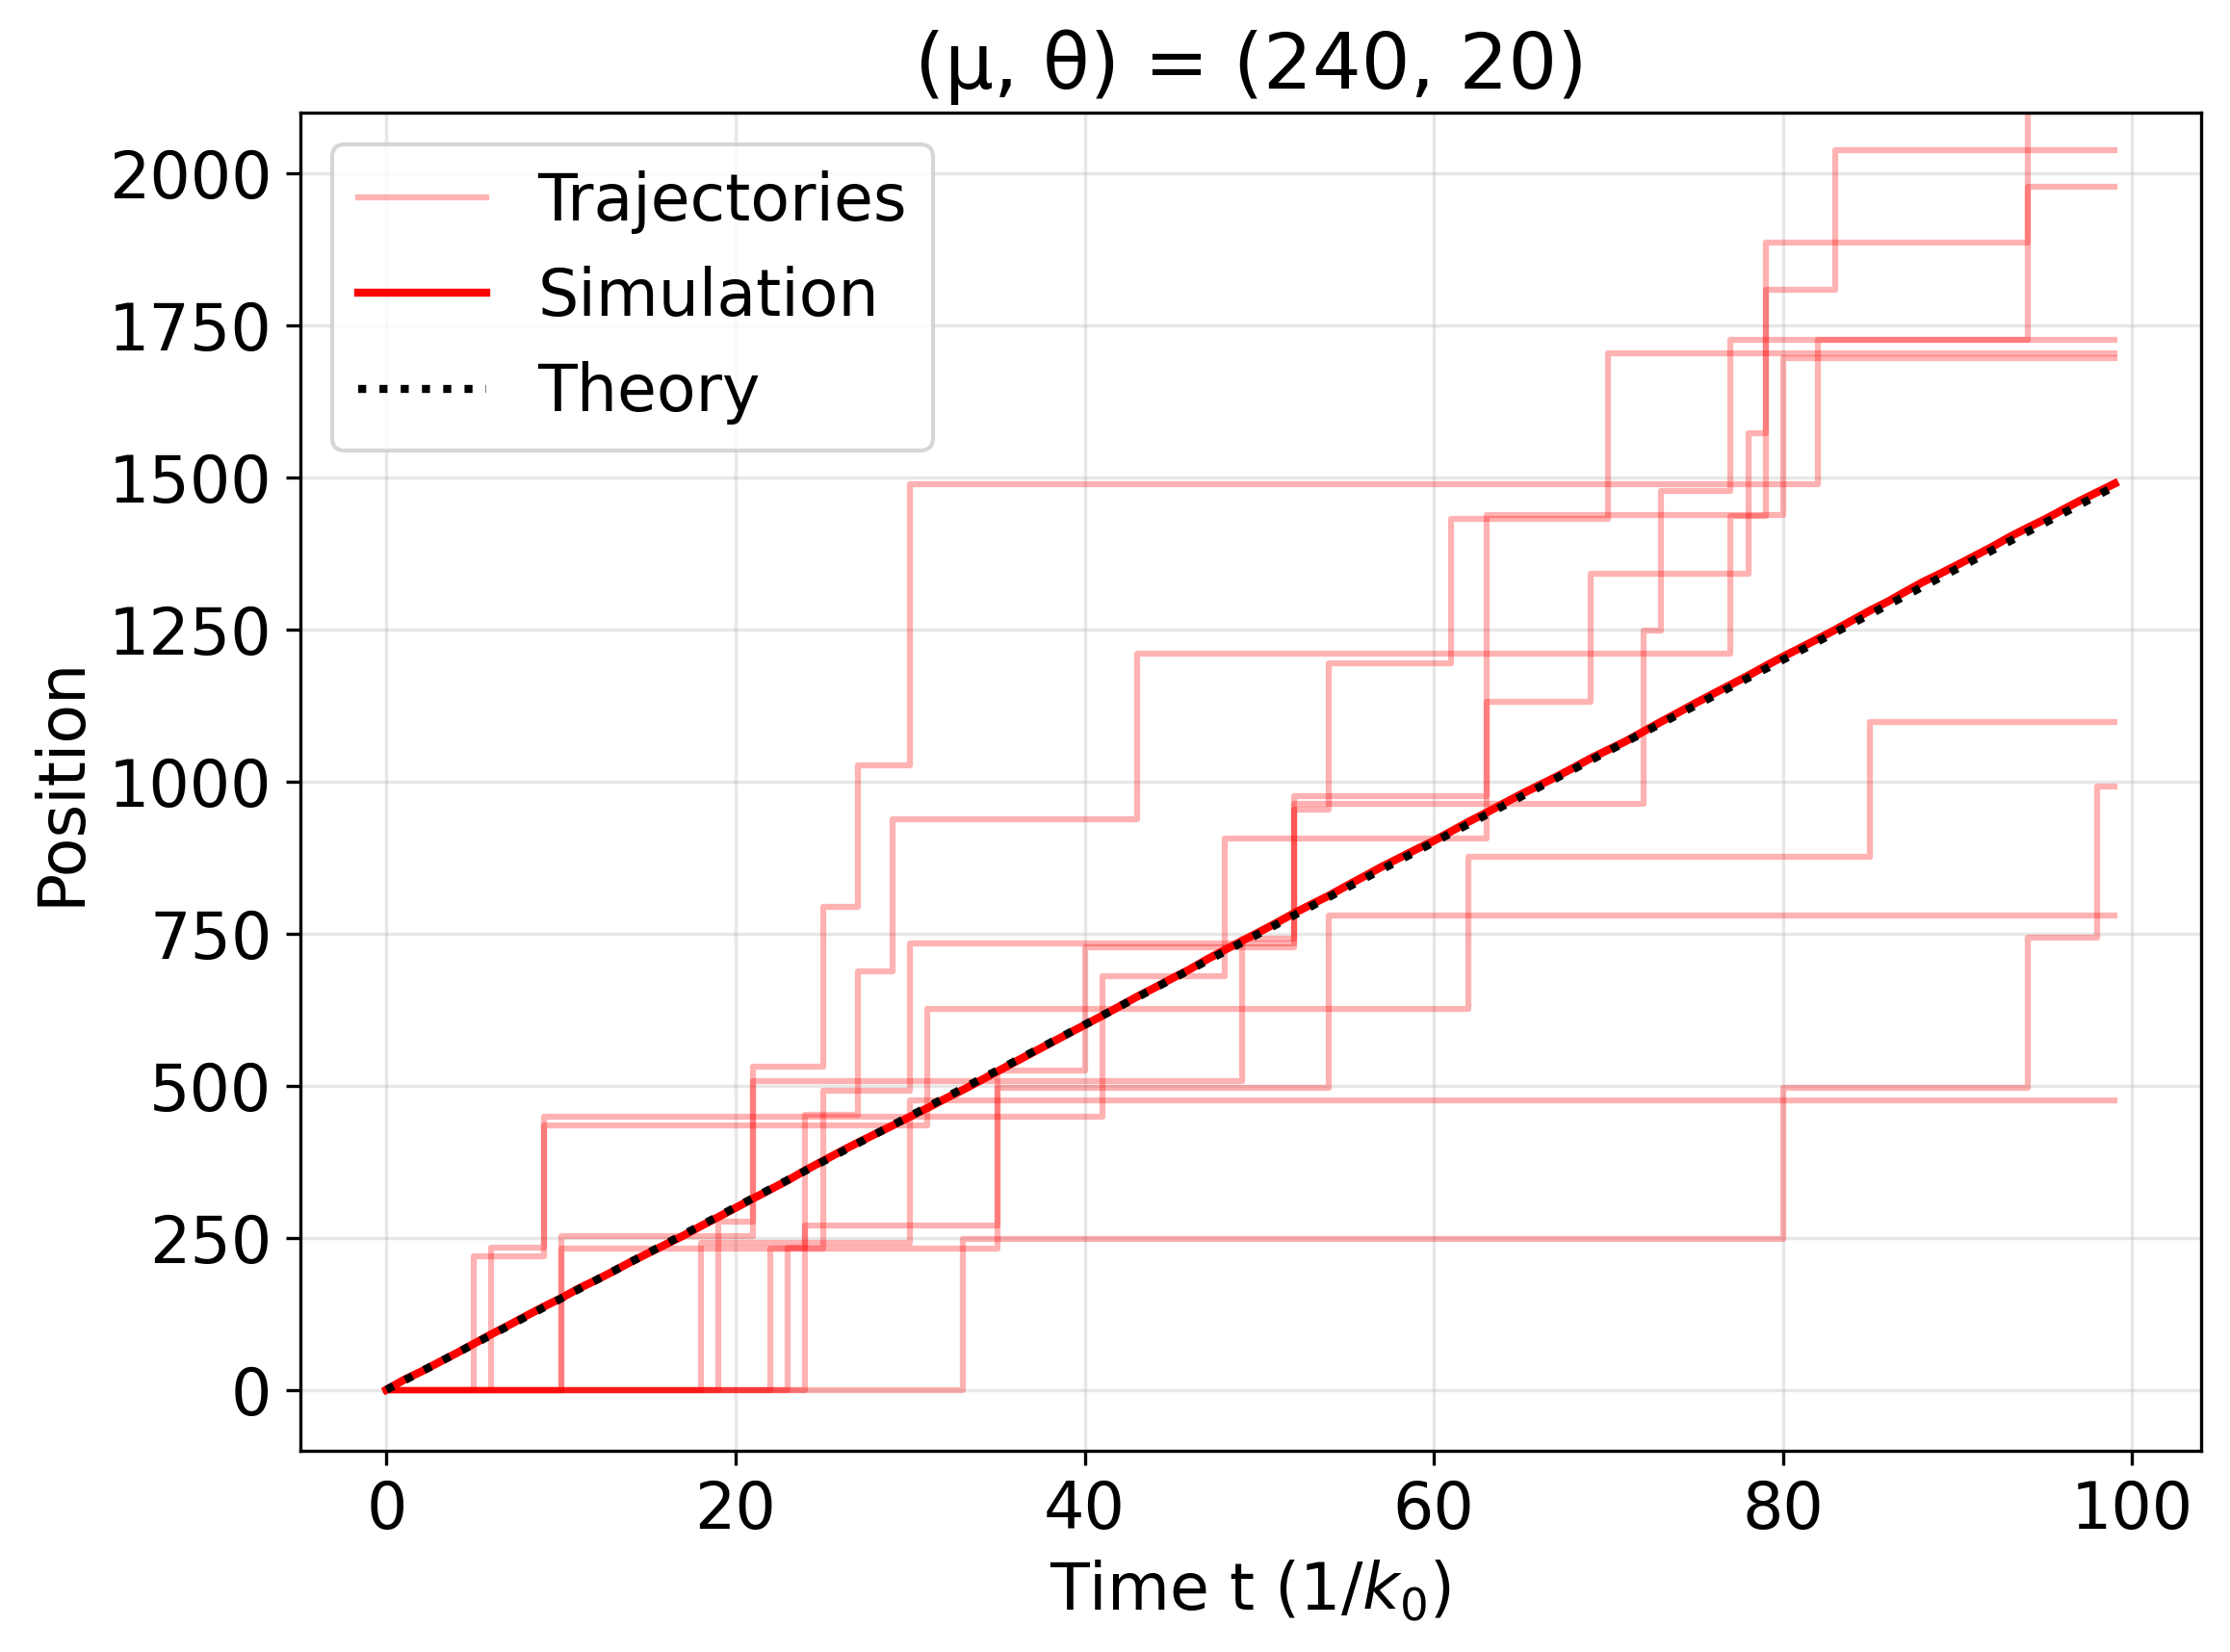

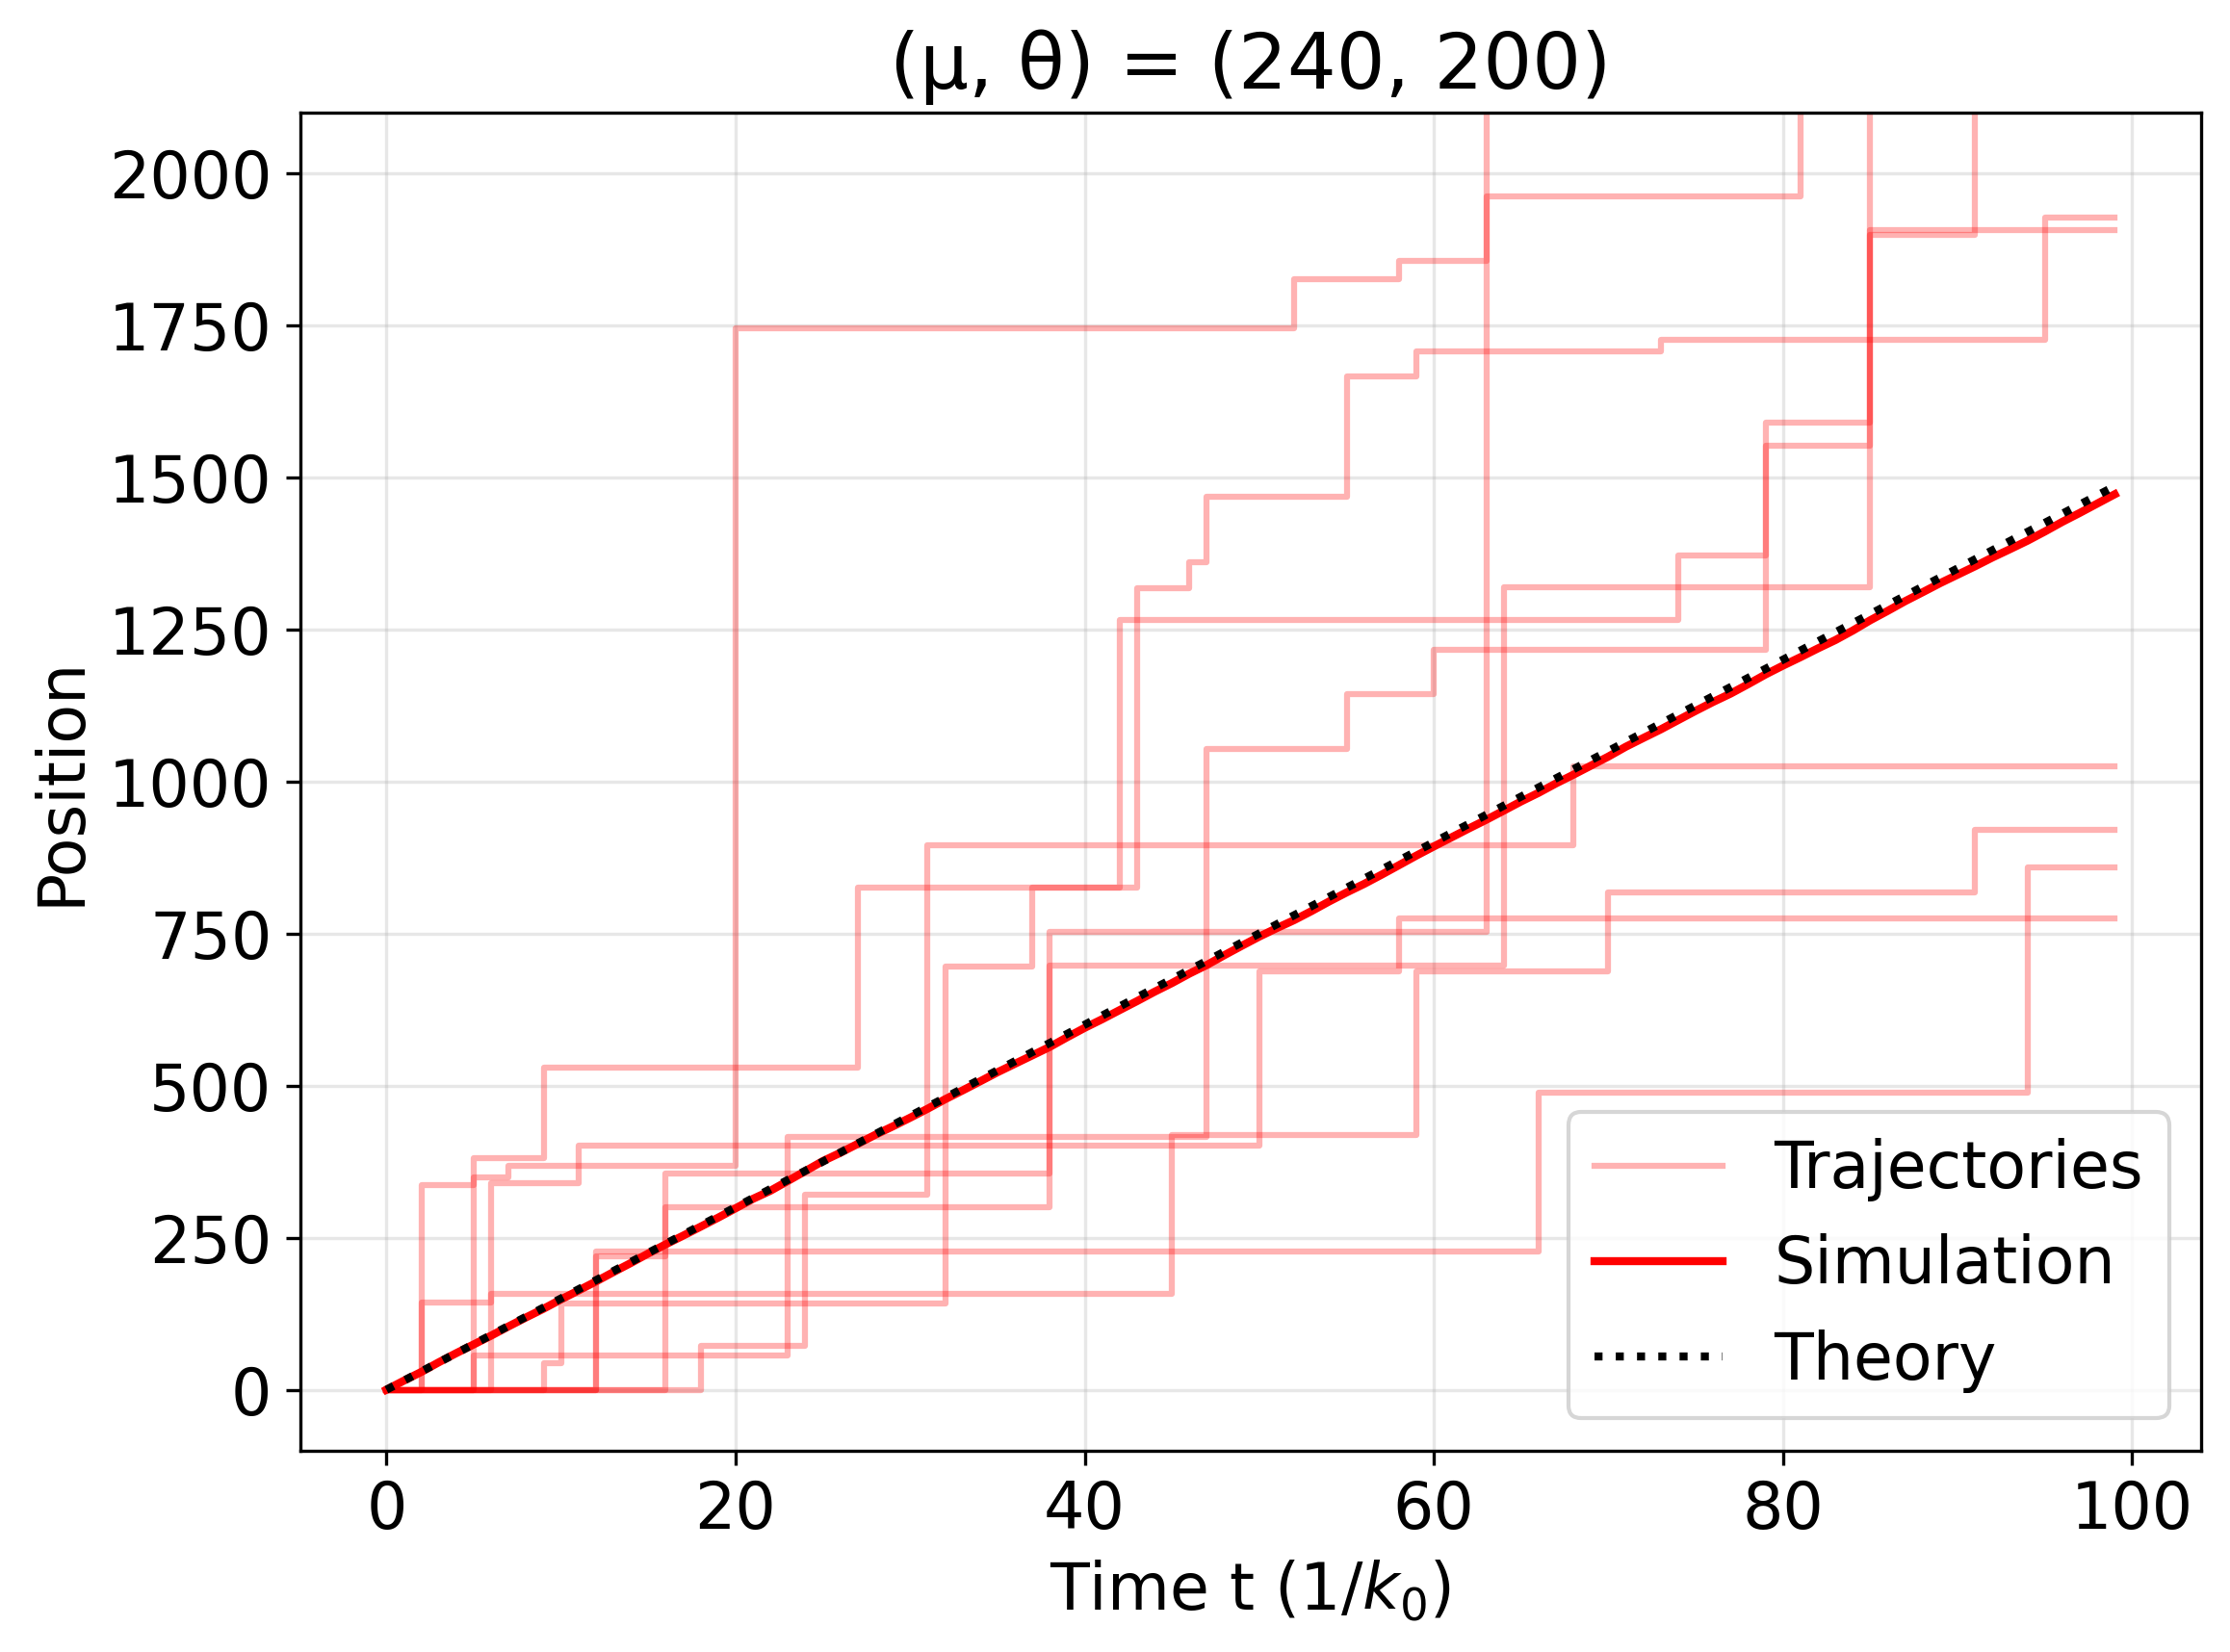

In [ ]:
from pathlib import Path
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

# --- Load files --- #
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/FIGURES__PC__2026-06-17/nucleo__fig2__0")
paths = sorted(str(p) for p in root.glob("*/**/*.parquet")) or sorted(str(p) for p in root.glob("*/*.parquet"))

df_all = (
    pl.scan_parquet(paths)
    .collect()
    .sort(by=[
        "algo", "fact", "mode",
        "land", "s", "l", "alphac", "alphar"
    ])
)

df_one = df_all.filter(pl.col("land") == "homogen")

# --- couples uniques --- #
pairs = (
    df_one.select(["mu", "theta"])
    .unique()
    .sort(["mu", "theta"])
    .to_numpy()
)

# --- loop --- #
for mu_val, theta_val in pairs:

    df_theta = df_one.filter(
        (pl.col("mu") == mu_val) &
        (pl.col("theta") == theta_val)
    )

    if df_theta.height == 0:
        continue

    # --- SAFE extraction --- #
    trajs = df_theta["results"][0]          # déjà une list/array
    mean_traj = df_theta["results_mean"][0]
    times = df_theta["times"][0]
    v_mean_th = df_theta["v_mean_th"][0]

    # mu peut être scalar ou array selon ton dataset
    mu = df_theta["mu"][0]

    # --- Plot --- #
    plt.figure(figsize=(8, 6), dpi=300)

    # trajectoires
    n_traj = min(10, len(trajs))
    for i in range(n_traj):
        plt.plot(trajs[i], drawstyle="steps-post",
                 color="red", alpha=0.3,
                 label="Trajectories" if i == 0 else None)

    # moyenne
    plt.plot(mean_traj,
             color="red", lw=2,
             label="Simulation")

    # théorie (IMPORTANT: scalaire attendu)
    plt.plot(times, np.array(times) * v_mean_th,
             color="black", lw=2, ls=":",
             label="Theory")

    plt.ylim([-100, 2100])
    plt.grid(alpha=0.3)
    plt.title(f"(μ, θ) = ({mu}, {theta_val})")
    plt.xlabel(r"Time t ($1/k_0$)")
    plt.ylabel("Position")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 2.B : Their distributions of speeds

In [3]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
plt.rcParams["font.size"] = 16

plt.figure(figsize=(8,6), dpi=1200)
thetas = np.unique(df_all["theta"].to_numpy())

def th_instantaneous_speeds(mu, theta, v, alpha0=10/160, k0=1):
    a = (mu / theta) ** 2
    b = mu / (theta ** 2)
    return (alpha0 * k0) * (a*b) * (v*b)**(a-1) / (alpha0*k0 + b*v)**(a+1)


cmap = cm.get_cmap("viridis")
n_colors = len(thetas)
color_positions = np.linspace(0.1, 0.4, n_colors)  # ajuste l’intervalle si besoin
color_list = [cmap(pos) for pos in color_positions]
color_list.reverse()


# v_mean (sans label)

MU = df_all["mu"].to_numpy()
l = df_all["l"].to_numpy()
s = df_all["s"].to_numpy()
alpha = l[0] / (l[0] + s[0])

plt.axvline(
    x=alpha * MU[0] / 2,
    color="black",
    ls=":",
    lw=2,
    alpha=1,
    label="_nolegend_"
)

for idx, theta_val in enumerate(thetas[0:3]):

    df_theta = df_all.filter(pl.col("theta") == theta_val)
    mu = df_theta["mu"][0]  # FIX: recalculé ici, ne plus dépendre de la cellule 2.A
    vi_points = df_theta["vi_points"][0].to_numpy()
    vi_distrib = df_theta["vi_distrib"][0].to_numpy()
    v_mean = df_theta["v_mean"].to_numpy()

    # =========================
    #  Ligne théorie v_init ~ alpha * (sigma k0)^-2
    # =========================

    alpha = 1  # ajuste si nécessaire pour que la courbe tombe au bon niveau
    init_points = vi_points[int(len(vi_points)/5000):]
    v_init = alpha * init_points**(-2)

    plt.plot(
        init_points,
        v_init * 30,
        color="black",
        ls="dashdot",
        lw=2.5,
        label=r"$\propto v_{i}^{-2}$"
    )

    ax = plt.gca()

    ax.text(
        0.98, 0.05,                         # (x,y) en coordonnées d'axe
        r"$\propto v^{-2}$",
        transform=ax.transAxes,
        fontsize=16,
        color="black",
        ha="right",
        va="bottom",
        rotation=-52
    )

    # Simulation (avec label couleur)
    plt.plot(
        vi_points,
        vi_distrib,
        color=color_list[idx],
        ls="-",
        lw=2,
        alpha=0.70,
        label=f"(μ,θ)=({mu},{theta_val})"
    )

    # Théorie (sans label)
    plt.plot(
        vi_points,
        th_instantaneous_speeds(mu, theta_val, vi_points),
        color=color_list[idx],
        ls="--",
        lw=2,
        alpha=0.70,
        label="_nolegend_"
    )


# =========================
#        LÉGENDES
# =========================

ax = plt.gca()

from matplotlib.lines import Line2D

# --- Lignes de style ---
style_legend = [
    Line2D([0], [0], color="black", lw=2, ls="-", label="Simulation"),
    Line2D([0], [0], color="black", lw=2, ls="--", label="Theory"),
    Line2D([0], [0], color="black", lw=2, ls=":", label=r"$v_{hom}/2$")
]

# --- Lignes de couleur pour θ ---
theta_labels = [r"$\theta={}$".format(t) for t in thetas]
color_legend = [Line2D([0], [0], color=color_list[i], lw=2, label=theta_labels[i]) 
                for i in range(len(thetas))]

# --- Combiner les deux ---
all_legend = style_legend + color_legend

# --- Ajouter la légende verticale ---
ax.legend(handles=all_legend, loc="upper right", frameon=True)  # pas de ncol = vertical


plt.xlabel(r'Velocity $v$ ($\sigma k_0$)')
plt.ylabel("Distribution")
plt.xlim([5e-1, 1e3])
plt.ylim([1e-4, 1e0])
plt.xscale("log")
plt.yscale("log")
plt.grid(True, alpha=0.3, which="both")

plt.show()

print(vi_points)

/tmp/ipykernel_11029/3042935190.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


[5.00000e-01 1.50000e+00 2.50000e+00 ... 9.99975e+04 9.99985e+04
 9.99995e+04]


/home/nicolas/Documents/Workspace/nucleo/src/nucleo/io/plots.py:458: RuntimeWarning: divide by zero encountered in log2
  data_to_plot = np.log2(data, dtype=float)
/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/lib/python3.12/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


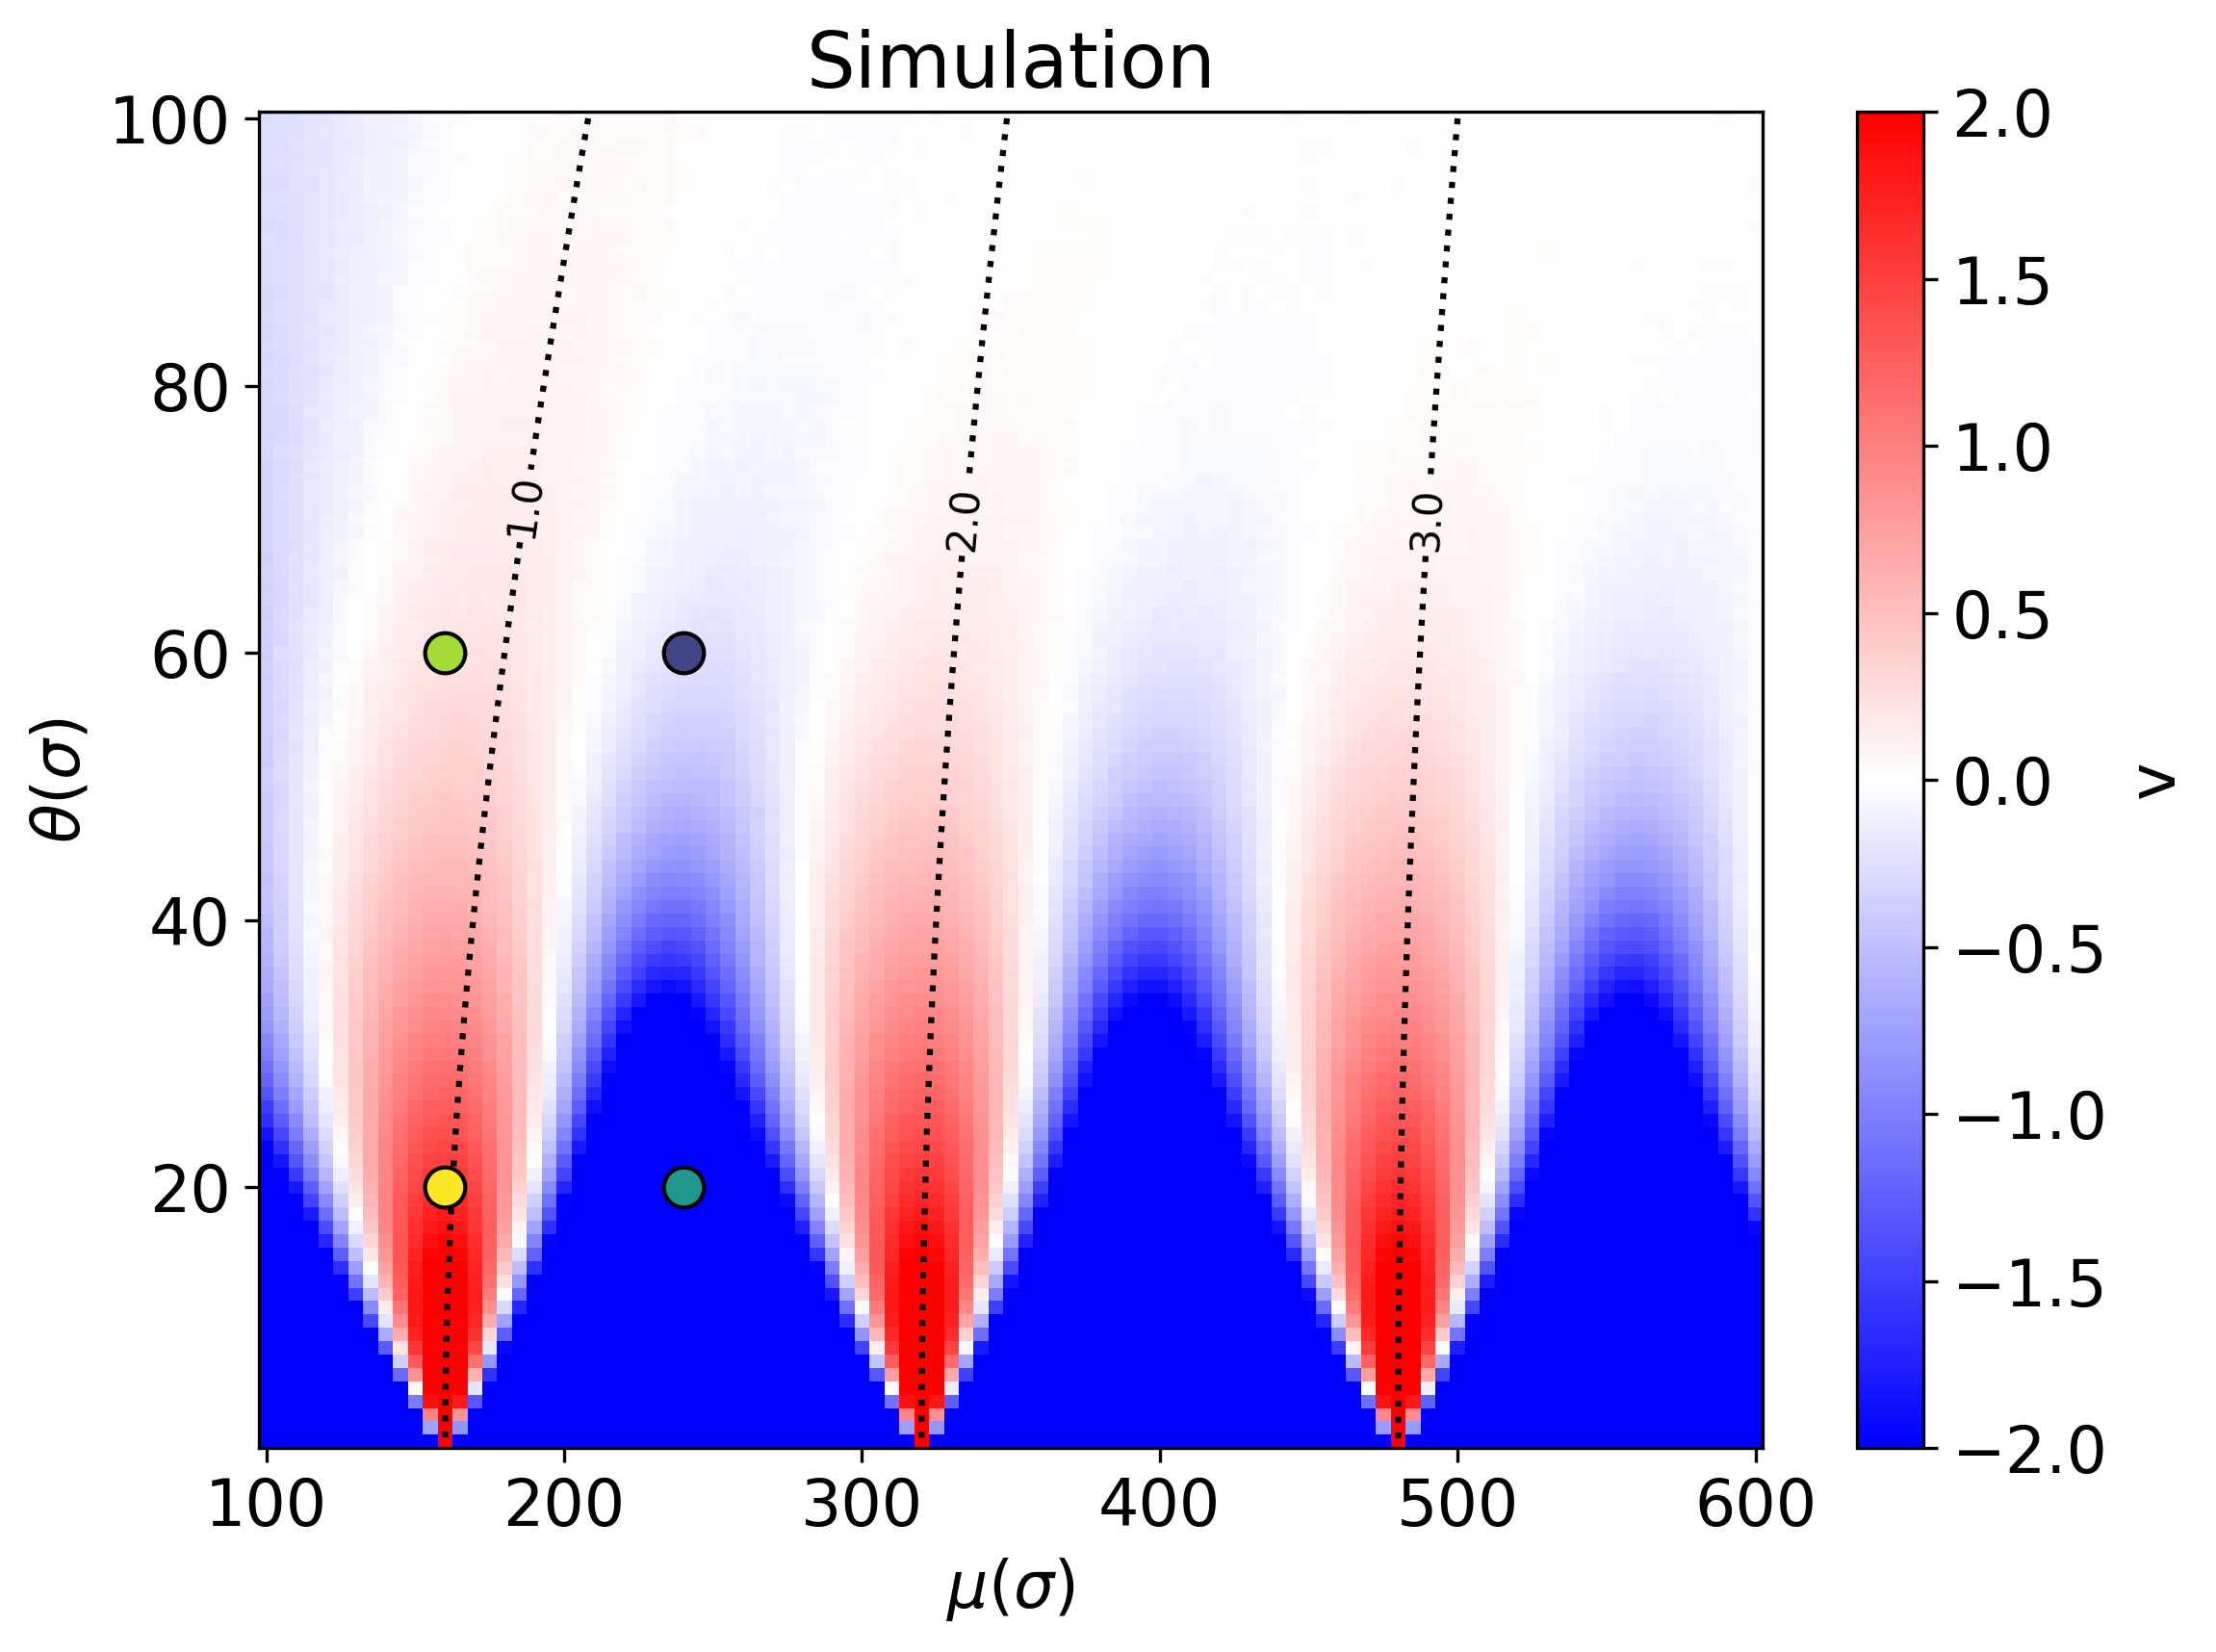

In [4]:
from pathlib import Path
from nucleo.io.reading import reading_heatmap_one_config
from nucleo.io.plots import plot_single_heatmap
from matplotlib import pyplot as plt
import numpy as np
plt.rcParams["font.size"] = 16



# Définition du root et de la configuration
root = Path.home() / "Documents" / "Workspace" / "nucleo" / "outputs" / "2025-01-01_PSMN"
config_to_plot = {
    "s": 150,
    "l": 10,
    "bpmin": 0,
    "alpha_choice": "periodic"
}

# Lecture des données
df_main, config_data = reading_heatmap_one_config(config_to_plot, "heatmap_th", root)

# Plot
fig, ax = plt.subplots(figsize=(8,6), dpi=300)
plot_single_heatmap(
    ax=ax,
    mu_values=config_data["mu_values"],
    theta_values=config_data["theta_values"],
    data=config_data["v_mean"],
    speed_col="v_mean",
    config=config_data["config"],
    plot_log2=True,
    vmin=-2,
    vmax=2,
    title_bar="v"
)


color_list= [
    (np.float64(0.993248), np.float64(0.906157), np.float64(0.143936), np.float64(1.0)), 
    (np.float64(0.647257), np.float64(0.8584), np.float64(0.209861), np.float64(1.0)), 
    (np.float64(0.120565), np.float64(0.596422), np.float64(0.543611), np.float64(1.0)), 
    (np.float64(0.253935), np.float64(0.265254), np.float64(0.529983), np.float64(1.0))
]

mus = np.array([160, 240])
thetas = np.array([20, 60])
points = [(160, 20), (160, 60), (240, 20), (240, 60)]

for i, (mu_pt, theta_pt) in enumerate(points):
    ax.scatter(
        mu_pt,
        theta_pt,
        color=color_list[i],
        s=100,          # taille du point
        edgecolor="black",  # contour du point
        zorder=10       # pour être au-dessus de la heatmap
    )

plt.tight_layout()
plt.show()

/tmp/ipykernel_198034/3770263363.py:39: RuntimeWarning: divide by zero encountered in log2
  data_plot = np.log2(v_theo / v_flat)
/tmp/ipykernel_198034/3770263363.py:39: RuntimeWarning: invalid value encountered in log2
  data_plot = np.log2(v_theo / v_flat)


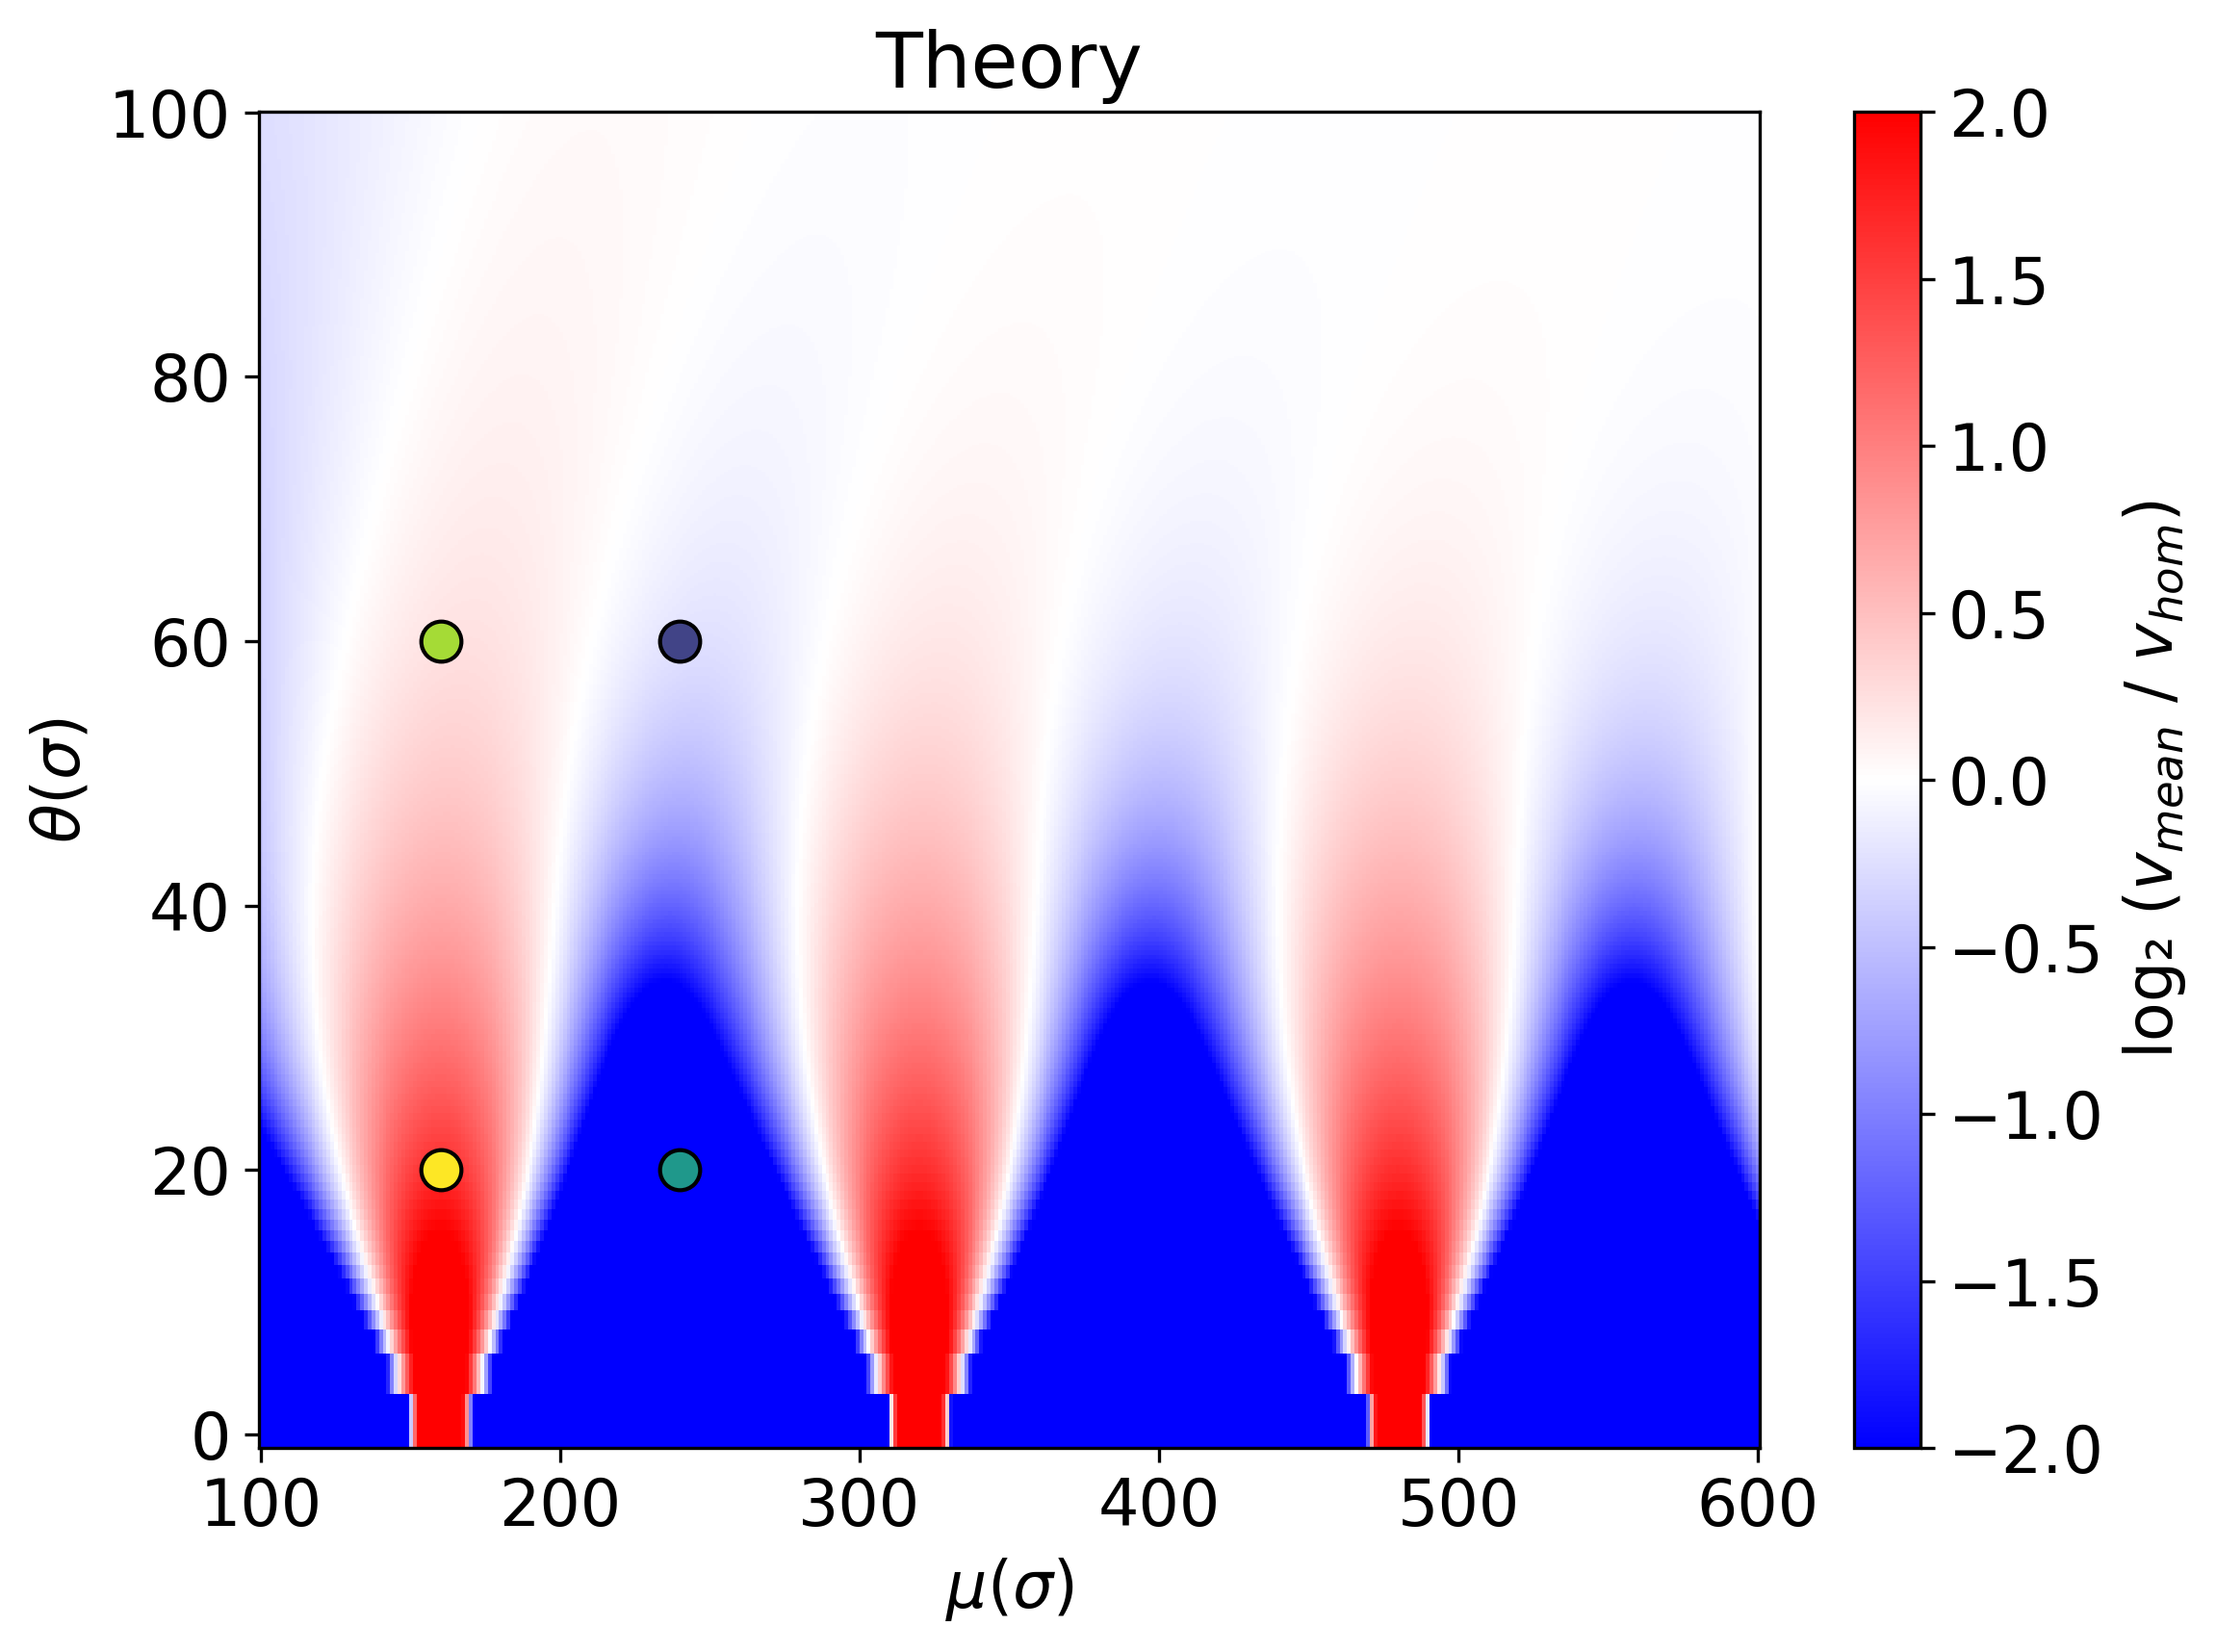

<Axes: title={'center': 'Theory'}, xlabel='$\\mu(\\sigma)$', ylabel='$\\theta(\\sigma)$'>

In [20]:
# ── Options ──────────────────────────────────────────────────────────────────
to_plot = "log2"   # "raw" | "log2"
alphaf, alphao = 1, 0
l, s = 10, 150
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 16
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/THEORY/")


def plot_v_theory(
    mu_vals,
    theta_vals,
    v_theo,
    to_plot="log2",        # "raw" | "log2"
    alphaf=1,
    alphao=0,
    l=10,
    s=150,
    points=None,
    color_list=None,
    ax=None,
    dpi=300,
):
    accessibility = (alphao * s + alphaf * l) / (s + l)
    v_flat = mu_vals * accessibility

    if to_plot == "raw":
        data_plot = v_theo
        vmin, vmax = None, None
        title_bar = r"$v_{mean}$"
        cmap = "viridis"
    elif to_plot == "log2":
        data_plot = np.log2(v_theo / v_flat)
        data_plot = np.nan_to_num(data_plot, nan=-2.0)
        if np.isnan(np.any(data_plot)):
            print("**")
        vmin, vmax = -2, 2
        title_bar = r"log₂ ($v_{mean}$ / $v_{hom}$)"
        cmap = "bwr"
    else:
        raise ValueError(f"to_plot must be 'raw' or 'log2', got '{to_plot}'")

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 6), dpi=dpi)
    else:
        fig = ax.get_figure()

    im = ax.pcolormesh(
        mu_vals,
        theta_vals,
        data_plot,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        shading="auto",
    )
    ax.set_title("Theory")
    ax.set_xlabel(r"$\mu(\sigma)$")
    ax.set_ylabel(r"$\theta(\sigma)$")

    if points:
        for i, (mu_pt, theta_pt) in enumerate(points):
            color = color_list[i] if color_list else f"C{i}"
            ax.scatter(mu_pt, theta_pt, color=color, s=100, edgecolor="black", zorder=10)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(title_bar)

    if standalone:
        plt.tight_layout()
        plt.show()

    return ax


# ── Main ─────────────────────────────────────────────────────────────────────
with open(root / "cesar_data.pkl", "rb") as f:
    data = pickle.load(f)

plot_v_theory(
    mu_vals=data["mu_vals"],
    theta_vals=data["sigma_vals"],
    v_theo=data["v_theo"],
    to_plot=to_plot,
    alphaf=alphaf,
    alphao=alphao,
    l=l,
    s=s,
    points=points,
    color_list=color_list,
)

# .